TODO:
- Select model(s)
  - Use temporal validation
- Generate preliminary results
- Create report

In [ ]:
# Drive Setup
import os
from google.colab import drive
# --- debugging prints ---
# brute force walk entire mounted drive and print all folder names
# for root, dirs, files in os.walk('/content/drive'):
#    for d in dirs:
#        print(os.path.join(root, d))
# print to find working directory
# print(os.listdir('/content/drive/'))
# print(os.listdir('/content/drive/MyDrive/CS3540'))
# print(os.listdir('/content/drive/MyDrive/snow_project'))

# create a personal shortcut to this shared folder located in your MyDrive
# by rightclick project folder and clicking add shortcut
drive.mount('/content/drive/')

GOOGLE_DRIVE_PATH_AFTER_MYDRIVE = 'snow_project'
GOOGLE_DRIVE_PATH = os.path.join('drive',
                                 'MyDrive',
                                 GOOGLE_DRIVE_PATH_AFTER_MYDRIVE)
#print(GOOGLE_DRIVE_PATH)
print(os.listdir(GOOGLE_DRIVE_PATH))

# Packages used for project
import datetime
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn
import scipy.stats as stats
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.base import clone
from sklearn.model_selection import cross_val_score

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
['data', 'Project Proposal Report.gdoc', 'project.ipynb']


## Wrangling & Exploratory Data Analysis

In [ ]:
# Read in data

data = pd.read_csv(f'{GOOGLE_DRIVE_PATH}/data/full.csv')
print(f"Data shape: {data.shape}")
data.head()

Data shape: (248684, 20)


,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,DAPR,DAPR_ATTRIBUTES,MDPR,MDPR_ATTRIBUTES,PRCP,PRCP_ATTRIBUTES,SNOW,SNOW_ATTRIBUTES,SNWD,SNWD_ATTRIBUTES,WESD,WESD_ATTRIBUTES,WESF,WESF_ATTRIBUTES
0,US1VTAD0038,"BRISTOL 3.9 NNW, VT US",44.184137,-73.12005,251.5,2024-05-20,NaN,NaN,NaN,NaN,0.0,",,N",0.0,",,N",NaN,NaN,NaN,NaN,NaN,NaN
1,US1VTAD0038,"BRISTOL 3.9 NNW, VT US",44.184137,-73.12005,251.5,2024-05-21,NaN,NaN,NaN,NaN,0.0,",,N",0.0,",,N",NaN,NaN,NaN,NaN,NaN,NaN
2,US1VTAD0038,"BRISTOL 3.9 NNW, VT US",44.184137,-73.12005,251.5,2024-05-22,NaN,NaN,NaN,NaN,21.8,",,N",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,US1VTAD0038,"BRISTOL 3.9 NNW, VT US",44.184137,-73.12005,251.5,2024-05-23,NaN,NaN,NaN,NaN,2.3,",,N",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,US1VTAD0038,"BRISTOL 3.9 NNW, VT US",44.184137,-73.12005,251.5,2024-05-24,NaN,NaN,NaN,NaN,0.0,",,N",0.0,",,N",NaN,NaN,NaN,NaN,NaN,NaN


Removed 0 stations with NO snow observations (114 → 114 stations)
Removing 12 additional stations with zero total snowfall across all years
Final station count: 102
Winter data shape: (133203, 12)
Winter years range: 2008 - 2025
Day of year range: 274 - 486
Total records after cleaning: 235,889
Winter records: 133,203
Unique stations: 102
Year range: 2009 - 2025

Columns: ['STATION', 'NAME', 'LATITUDE', 'LONGITUDE', 'ELEVATION', 'PRCP', 'SNOW', 'SNWD', 'year', 'month', 'day_of_year', 'winter_year']


,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,PRCP,SNOW,SNWD,year,month,day_of_year,winter_year
284,US1VTWH0029,"BRATTLEBORO 0.7 S, VT US",42.8403,-72.5558,117.3,0.0,0.0,NaN,2018,11,313,2018
285,US1VTWH0029,"BRATTLEBORO 0.7 S, VT US",42.8403,-72.5558,117.3,19.8,NaN,NaN,2018,11,314,2018
286,US1VTWH0029,"BRATTLEBORO 0.7 S, VT US",42.8403,-72.5558,117.3,0.0,NaN,NaN,2018,11,315,2018
287,US1VTWH0029,"BRATTLEBORO 0.7 S, VT US",42.8403,-72.5558,117.3,0.0,0.0,NaN,2018,11,316,2018
288,US1VTWH0029,"BRATTLEBORO 0.7 S, VT US",42.8403,-72.5558,117.3,13.5,NaN,NaN,2018,11,317,2018


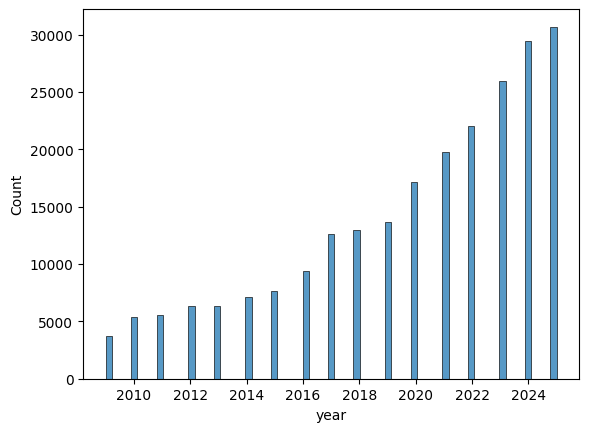

In [ ]:
# Parse DATE and extract useful columns
data['DATE'] = pd.to_datetime(data['DATE'])
data['year'] = data['DATE'].dt.year.astype(int)
data['month'] = data['DATE'].dt.month.astype(int)
data['day_of_year'] = data['DATE'].dt.dayofyear.astype(int)

# Keep only 2009 and onward
data = data[(data['year'] >= 2009) & (data['year'] <= 2025)].copy()

# Dropping the original DATE column
data.drop('DATE', axis = 1, inplace = True, errors = 'ignore')

# Dropping attribute columns
attr_cols = [c for c in data.columns if c.endswith('_ATTRIBUTES')]
data.drop(columns = attr_cols, inplace = True, errors = 'ignore')

# Dropping columns that are almost entirely NaN
for col in ['DAPR', 'MDPR', 'WESD', 'WESF']:
    if col in data.columns:
        data.drop(columns = col, inplace = True, errors = 'ignore')


# identify stations that have at least 1 not NaN SNOW reading
stations_with_snow = (
    data.groupby('STATION')['SNOW']
    .apply(lambda x: x.notna().sum())
    .reset_index(name = 'snow_obs_count')
)
valid_stations = stations_with_snow.loc[stations_with_snow['snow_obs_count'] > 0, 'STATION']
# calculate how many stations we removed based on the zero filter
n_before = data['STATION'].nunique()
data = data[data['STATION'].isin(valid_stations)].copy()
n_after = data['STATION'].nunique()
print(f"Removed {n_before - n_after} stations with NO snow observations "
      f"({n_before} → {n_after} stations)")

# remove stations whose total seasonal snow is 0 across all recorded winters
# assuming that no VT location will go a winter without snow
station_total_snow = data.groupby('STATION')['SNOW'].sum()
zero_snow_stations = station_total_snow[station_total_snow == 0].index
if len(zero_snow_stations) > 0:
    print(f"Removing {len(zero_snow_stations)} additional stations with "
          f"zero total snowfall across all years")
    data = data[~data['STATION'].isin(zero_snow_stations)].copy()

print(f"Final station count: {data['STATION'].nunique()}")


# 'winter_year' Oct-Dec belong to that years winter
# Jan-May belong to previous years winter
# Oct 2020 - May 2021 : winter_year = 2020
data['winter_year'] = np.where(data['month'] >= 10,
                               data['year'],
                               data['year'] - 1)

# winter months only
winter_data = data[data['month'].isin([10, 11, 12, 1, 2, 3, 4])].copy()

# 'day_of_year' that increases through the winter season
# Oct 1 = DOY 274, we want Oct-Dec to keep their normal DOY
# We also want Jan- Apr to have DOY + 365 so the season is continuous
winter_data['day_of_year'] = np.where(
    winter_data['month'] >= 10,
    winter_data['day_of_year'], # Oct-Dec: keep normal DOY 274-365
    winter_data['day_of_year'] + 365 # Jan-Apr: shift forward 366-516
)

# Printing the output for better visualization
print(f"Winter data shape: {winter_data.shape}")
print(f"Winter years range: {winter_data['winter_year'].min()} - {winter_data['winter_year'].max()}")
print(f"Day of year range: {winter_data['day_of_year'].min()} - {winter_data['day_of_year'].max()}")

# Summary of all records after data cleanup
print(f"Total records after cleaning: {len(data):,}")
print(f"Winter records: {len(winter_data):,}")
print(f"Unique stations: {winter_data['STATION'].nunique()}")
print(f"Year range: {winter_data['year'].min()} - {winter_data['year'].max()}")
print(f"\nColumns: {list(data.columns)}")

# Plotting and showing the first few items in the data
sns.histplot(data['year'])
data.head()

Heavily skewed left. Seems like 2009 is an adequate cutoff year.

# Station Level Seasonal Aggregation

In [ ]:
# Seasonal totals per station per winter year
def first_snow_doy(group):
    # Day of year of first snowfall > 0 in the season
    snow_days = group[group['SNOW'] > 0]
    if len(snow_days) == 0:
        return np.nan
    return snow_days['day_of_year'].iloc[0]

def last_snow_doy(group):
    # Day of year of last snowfall > 0 in the season
    snow_days = group[group['SNOW'] > 0]
    if len(snow_days) == 0:
        return np.nan
    return snow_days['day_of_year'].iloc[-1]

# Sorting by date within each station season for correct first last
winter_data_sorted = winter_data.sort_values(['STATION', 'winter_year', 'year', 'month'])

seasonal_stats = winter_data_sorted.groupby(['STATION', 'NAME', 'winter_year']).agg(
    total_snow = ('SNOW', lambda x: x.dropna().sum()), # sum only reported days
    total_prcp = ('PRCP', 'sum'),
    max_snow_depth = ('SNWD', 'max'),
    mean_snow_depth = ('SNWD', 'mean'),
    snow_days = ('SNOW', lambda x: (x.dropna() > 0).sum()),
    snow_obs_days = ('SNOW', lambda x: x.notna().sum()), # how many days actually reported
    season_length = ('day_of_year', lambda x: x.max() - x.min() + 1),
    latitude = ('LATITUDE', 'first'),
    longitude = ('LONGITUDE', 'first'),
    elevation = ('ELEVATION', 'first'),
).reset_index()

# First and last snow dates per station season
first_last = winter_data_sorted.groupby(['STATION', 'winter_year']).apply(
    lambda g: pd.Series({
        'first_snow_doy': first_snow_doy(g),
        'last_snow_doy': last_snow_doy(g),
    }),
    include_groups = False
).reset_index()

# Left join merging 'STATION' and 'winter_year' and removing unmatched data
seasonal_stats = seasonal_stats.merge(first_last, on = ['STATION', 'winter_year'], how = 'left')

# Snow season duration days between first and last snowfall
seasonal_stats['snow_season_days'] = seasonal_stats['last_snow_doy'] - seasonal_stats['first_snow_doy']

# Computing snow to precipitation ratio where total_prcp > 0
seasonal_stats['snow_prcp_ratio'] = np.where(
    seasonal_stats['total_prcp'] > 0,
    seasonal_stats['total_snow'] / seasonal_stats['total_prcp'],
    0)

# Drop station seasons with zero total snow
n_before_zero = len(seasonal_stats)
seasonal_stats = seasonal_stats[seasonal_stats['total_snow'] > 0].copy()
print(f"Dropped {n_before_zero - len(seasonal_stats)} station-seasons with "
      f"zero total snow (data coverage artifacts)")


# Require at minimum x many days of SNOW observations in a season
# full Oct–Apr season is ~212 days
MIN_OBS_DAYS = 30
before_filter = len(seasonal_stats)
seasonal_stats = seasonal_stats[
    seasonal_stats['snow_obs_days'] >= MIN_OBS_DAYS
].copy()
after_filter = len(seasonal_stats)
print(f"\nFiltered out {before_filter - after_filter} sparse station-seasons "
      f"(< {MIN_OBS_DAYS} SNOW obs days): {before_filter} → {after_filter}")

# stations ranked by lowest mean seasonal snowfall
station_snow_summary = seasonal_stats.groupby(['STATION', 'NAME']).agg(
    mean_season_snow=('total_snow', 'mean'),
    min_season_snow=('total_snow', 'min'),
    n_seasons=('winter_year', 'count'),
).reset_index().sort_values('mean_season_snow')

print(f"Stations with lowest mean seasonal snowfall")
print(station_snow_summary.head(10).to_string(index = False))


# Showing summary of seasonal stats
print(f"\nSeasonal stats summary:")
print(seasonal_stats[['total_snow', 'total_prcp', 'max_snow_depth', 'snow_days',
                       'snow_season_days', 'snow_prcp_ratio']].describe())

Dropped 77 station-seasons with zero total snow (data coverage artifacts)

Filtered out 64 sparse station-seasons (< 30 SNOW obs days): 784 → 720
Stations with lowest mean seasonal snowfall
    STATION                         NAME  mean_season_snow  min_season_snow  n_seasons
US1VTWS0036        DUXBURY 2.5 SW, VT US          9.020000              0.3          5
US1VTLM0016   MORRISVILLE 1.2 ESE, VT US         40.000000             40.0          1
US1VTCL0019  EAST HARDWICK 0.4 SE, VT US         56.600000              7.0          5
US1VTFR0029      FLETCHER 0.7 SSW, VT US         59.266667             42.5          3
US1VTWS0047 EAST MONTPELIER 0.7 W, VT US         64.250000             31.9          2
US1VTWH0019      EAST DOVER 1.8 N, VT US         64.337500             20.0          8
US1VTWS0015    EAST CALAIS 1.5 SW, VT US         68.350000             27.0         14
US1VTFR0021       FAIRFAX 4.9 WNW, VT US         68.357143             33.8          7
US1VTFR0026  ENOSBURG FALLS

# Regional Clustering of Stations (AGGREGATE DOES NOT WORK YET)

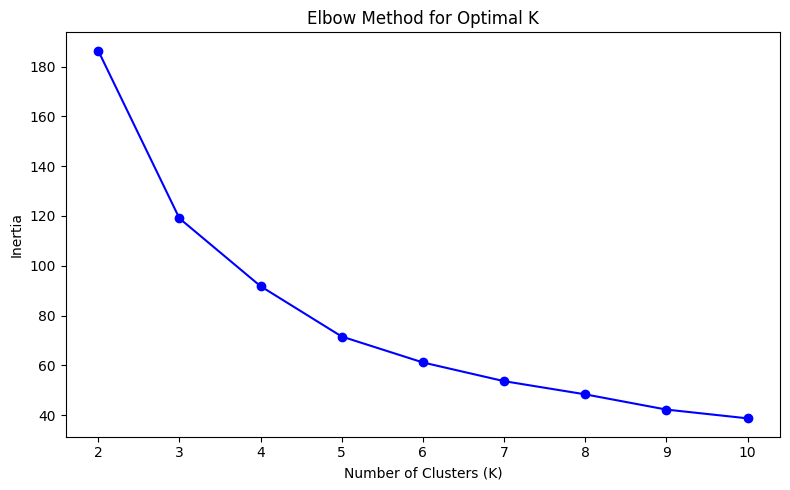

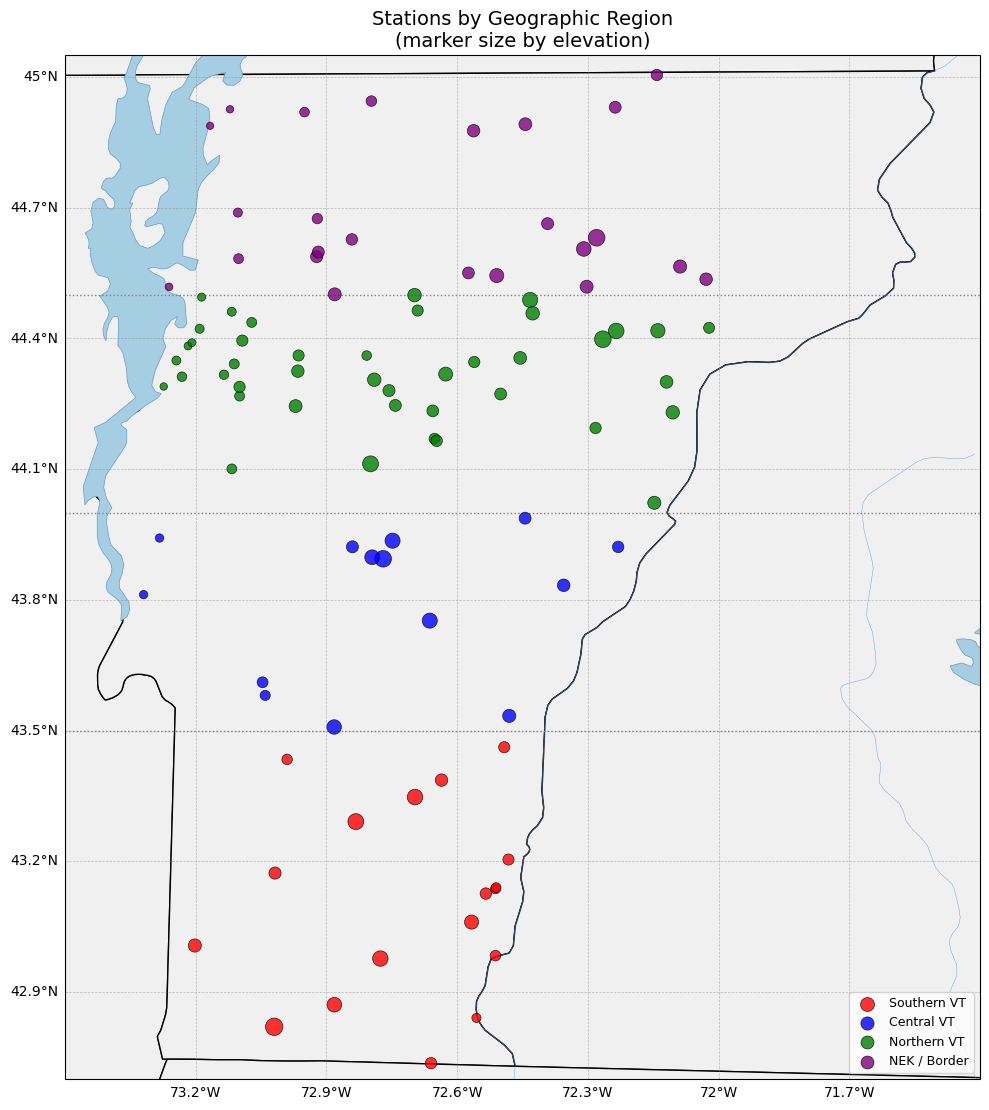

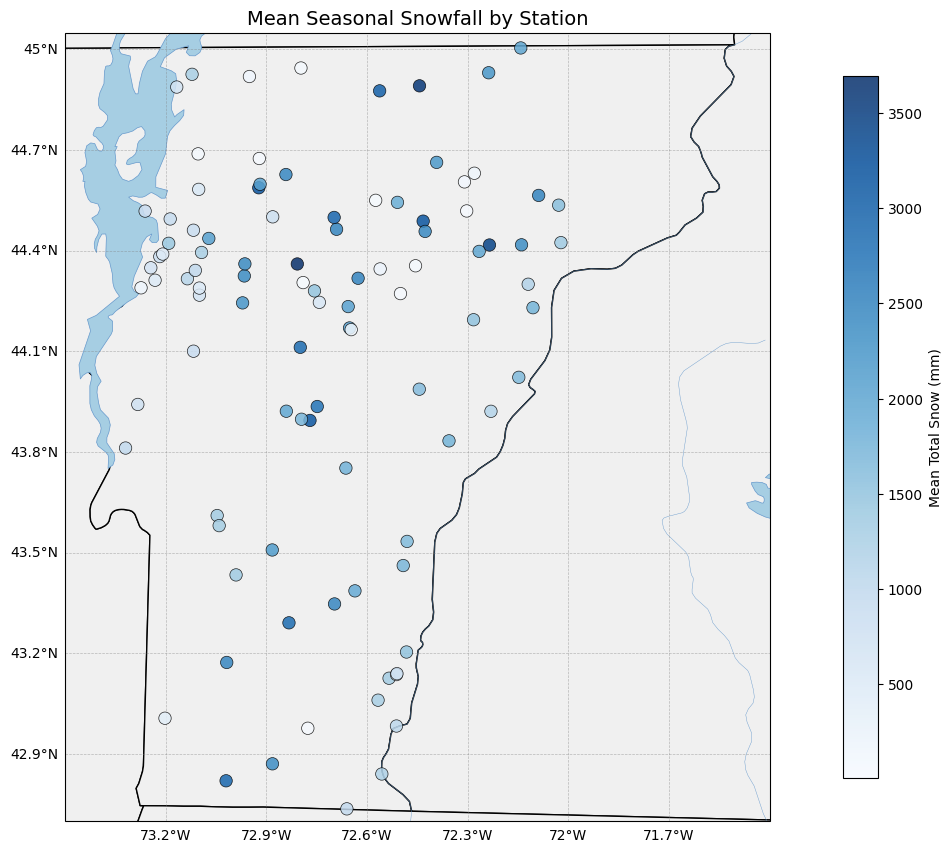


Stations per county region:
county_region_name
Central VT      14
NEK / Border    24
Northern VT     42
Southern VT     18
Name: count, dtype: int64

Stations per K-means region:
kmeans_region
0    32
1    12
2    38
3    16
Name: count, dtype: int64


In [ ]:
# Station metadata for clustering
station_meta = seasonal_stats.groupby('STATION').agg(
    latitude = ('latitude', 'first'),
    longitude = ('longitude', 'first'),
    elevation = ('elevation', 'first'),
    mean_total_snow = ('total_snow', 'mean'),
    name = ('NAME', 'first'),
).reset_index()

# vermont in quarter regions
# Region 0 Southern VT  (lat < 43.50)
# Region 1 Central VT   (43.50 <= lat < 44.00)
# Region 2 Northern VT  (44.00 <= lat < 44.50)
# Region 3 NEK / Border (lat >= 44.50)

def assign_county_region(lat):
    # geographic region based on latitude bands
    if lat < 43.50:
        return 0 # Southern VT
    elif lat < 44.00:
        return 1 # Central VT
    elif lat < 44.50:
        return 2 # Northern VT
    else:
        return 3 # Northeast Kingdom
station_meta['county_region'] = station_meta['latitude'].apply(assign_county_region)

COUNTY_REGION_NAMES = {
    0: 'Southern VT',
    1: 'Central VT',
    2: 'Northern VT',
    3: 'NEK / Border',
}
station_meta['county_region_name'] = station_meta['county_region'].map(COUNTY_REGION_NAMES)

# Standardizing clustering features
cluster_features = ['latitude', 'longitude', 'elevation']
scaler = StandardScaler()
X_cluster = scaler.fit_transform(station_meta[cluster_features].values)

# Optimal K using elbow method
inertias = []
K_range = range(2, min(11, len(station_meta)))
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

# Plotting the elbow method
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(list(K_range), inertias, 'bo-')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method for Optimal K')
plt.tight_layout()
plt.show()

# Using K=4
optimal_k = min(4, len(station_meta) - 1)
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
# based on k means cliuster
station_meta['kmeans_region'] = kmeans.fit_predict(X_cluster)
# based on quarter split of VT
station_meta['region'] = station_meta['county_region']

# Merging region labels back to seasonal stats
seasonal_stats = seasonal_stats.merge(
    station_meta[['STATION', 'region', 'county_region_name', 'kmeans_region']],
    on = 'STATION', how = 'left'
)

# Vermont bounding box
# Using cartopy for drawing VT map, scale is currently a little weird
VT_LON_MIN, VT_LON_MAX = -73.50, -71.40
VT_LAT_MIN, VT_LAT_MAX = 42.70, 45.05

def create_vermont_map_axis(fig, position=111):
    # Create matplotlib axis with Vermont outline map background & lat/lon grid
    ax = fig.add_subplot(position, projection=ccrs.PlateCarree())
    ax.set_extent([VT_LON_MIN, VT_LON_MAX, VT_LAT_MIN, VT_LAT_MAX],
                  crs=ccrs.PlateCarree())

    # State boundaries 10m resolution
    ax.add_feature(cfeature.STATES.with_scale('10m'),
                   linewidth=1.0,
                   edgecolor='black',
                   facecolor='#f0f0f0')
    # Land/water coloring for context
    ax.add_feature(cfeature.LAND.with_scale('10m'),
                   facecolor="#f9f9f8",
                   zorder=0)
    ax.add_feature(cfeature.LAKES.with_scale('10m'),
                   facecolor='#a6cee3',
                   edgecolor='#6699cc',
                   linewidth=0.5)
    ax.add_feature(cfeature.RIVERS.with_scale('10m'),
                   edgecolor='#6699cc',
                   linewidth=0.3)

    # Lat/lon gridlines
    gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray',
                      alpha=0.5, linewidth=0.5)
    gl.top_labels = False
    gl.right_labels = False

    return ax


# Station clusters on Vermont map
fig = plt.figure(figsize=(10, 12))
ax = create_vermont_map_axis(fig)

colors = {0: 'red', 1: 'blue', 2: 'green', 3: 'purple'}
for region_id, region_name in COUNTY_REGION_NAMES.items():
    subset = station_meta[station_meta['county_region'] == region_id]
    ax.scatter(subset['longitude'], subset['latitude'],
               c = colors[region_id], label = region_name,
               s = subset['elevation'] / 5 + 20, alpha = 0.8,
               edgecolors = 'black', linewidth = 0.5,
               transform = ccrs.PlateCarree(), zorder = 5)

ax.set_title('Stations by Geographic Region\n(marker size by elevation)', fontsize=14)
ax.legend(loc = 'lower right', fontsize=9)
# latitude boundaries
for lat_line in [43.50, 44.00, 44.50]:
    ax.plot([VT_LON_MIN, VT_LON_MAX], [lat_line, lat_line],
            color='gray', linestyle=':', linewidth=1,
            transform=ccrs.PlateCarree())
plt.tight_layout()
plt.show()

# Mean seasonal snowfall
fig = plt.figure(figsize = (10, 12))
ax = create_vermont_map_axis(fig)
scatter2 = ax.scatter(
    station_meta['longitude'], station_meta['latitude'],
    c = station_meta['mean_total_snow'], cmap = 'Blues', s = 80,
    alpha = 0.85, edgecolors = 'black', linewidth = 0.5,
    transform = ccrs.PlateCarree(), zorder = 5)
ax.set_title('Mean Seasonal Snowfall by Station', fontsize  =14)
# make a legend to show what color intensity represents
plt.colorbar(scatter2, ax=ax, label = 'Mean Total Snow (mm)', shrink = 0.6, pad = 0.08)
plt.tight_layout()
plt.show()

print(f"\nStations per county region:")
print(station_meta['county_region_name'].value_counts().sort_index())
print(f"\nStations per K-means region:")
print(station_meta['kmeans_region'].value_counts().sort_index())

# Set Up Features to use, more data cleaning

In [ ]:
LAG_YEARS = [1, 2, 3]

# maps output column prefix to source column for lagging by yrs
LAG_COLS = {
    "snow": "total_snow",
    "prcp": "total_prcp",
    "snow_days": "snow_days",
    "ratio": "snow_prcp_ratio",
}

# all feature columns getting fed into models
FEATURE_COLS = [
    "latitude", "longitude", "elevation", "region",  # station metadata
    "year_numeric", # trend year offset
    *[f"{name}_lag{lag}" for lag in LAG_YEARS for name in LAG_COLS], # lag features naming
    "snow_roll3", "snow_roll5", # rolling snow averages for 3yr or 5yr
]

TARGET_COL = "total_snow"

# fix features
# sort so lags and rolling windows are computed in chronological order per station
ml_data = seasonal_stats.sort_values(["STATION", "winter_year"]).copy()
# lag features shift each source column back 1, 2, 3 winters per station
for name, source_col in LAG_COLS.items():
    for lag in LAG_YEARS:
        ml_data[f"{name}_lag{lag}"] = ml_data.groupby("STATION")[source_col].shift(lag)

# rolling averages shift(1) first so current year is never included in its own average
ml_data["snow_roll3"] = ml_data.groupby("STATION")["total_snow"].transform(
    lambda x: x.shift(1).rolling(3, min_periods = 1).mean()
)
ml_data["snow_roll5"] = ml_data.groupby("STATION")["total_snow"].transform(
    lambda x: x.shift(1).rolling(5, min_periods = 1).mean()
)

# year offset from the earliest winter in the dataset, captures long term trend
ml_data["year_numeric"] = ml_data["winter_year"] - ml_data["winter_year"].min()

# drop any row missing a feature or the target, which is expected for first 1-3 years per station
ml_ready = ml_data.dropna(subset = FEATURE_COLS + [TARGET_COL]).copy()


print(f"ML ready samples: {len(ml_ready)}")
print(f"Features: {len(FEATURE_COLS)}")
print(f"Winter year range: {ml_ready['winter_year'].min()} - {ml_ready['winter_year'].max()}")

ML ready samples: 451
Features: 19
Winter year range: 2011 - 2025


# Train Test Split and Model Instances, Cross Validation

In [ ]:
# train on earlier years, test on recent ones
# split everything before last 3 winter years = train last 3 = test
max_year = ml_ready['winter_year'].max()
test_years = [max_year - 2, max_year - 1, max_year]
# training is not (~) in test years we define above
train_mask = ~ml_ready['winter_year'].isin(test_years)
test_mask = ml_ready['winter_year'].isin(test_years)

X_train = ml_ready.loc[train_mask, FEATURE_COLS].values
y_train = ml_ready.loc[train_mask, TARGET_COL].values
X_test = ml_ready.loc[test_mask, FEATURE_COLS].values
y_test = ml_ready.loc[test_mask, TARGET_COL].values

print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")
print(f"Train years: {ml_ready.loc[train_mask, 'winter_year'].min()} - "
      f"{ml_ready.loc[train_mask, 'winter_year'].max()}")
print(f"Test years: {sorted(ml_ready.loc[test_mask, 'winter_year'].unique())}")

# scale features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# define models to use
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha = 1.0),
    'Lasso Regression': Lasso(alpha = 1.0, max_iter = 10000),
    'Random Forest': RandomForestRegressor(
        n_estimators = 200, max_depth = 15, min_samples_leaf = 5, random_state = 42, n_jobs = -1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators = 200, max_depth = 5, learning_rate = 0.1, random_state = 42
    ),
}




# Time Series cross validation on training set
# TimeSeriesSplit w 5 folds so ordering stays
tscv = TimeSeriesSplit(n_splits = 5)

# need indices sorted by winter_year for proper temporal CV
train_df = ml_ready.loc[train_mask].sort_values('winter_year').reset_index(drop = True)
X_train_cv = train_df[FEATURE_COLS].values
y_train_cv = train_df[TARGET_COL].values
scaler_cv = StandardScaler()
X_train_cv_scaled = scaler_cv.fit_transform(X_train_cv)

print("Time Series Cross Validation 5 folds")
cv_results = {}
for name, model in models.items():
    X_cv = X_train_cv_scaled if (not ('Forest' in name or 'Boosting' in name)) else X_train_cv
    scores = cross_val_score(
        clone(model), X_cv, y_train_cv,
        cv = tscv, scoring = 'neg_root_mean_squared_error', n_jobs = -1
    )
    cv_rmse = -scores  # negate because sklearn returns negative RMSE
    cv_results[name] = {
        'CV Mean RMSE': cv_rmse.mean(),
        'CV Std RMSE':  cv_rmse.std(),
    }
    print(f"{name}:  RMSE = {cv_rmse.mean():.2f} +- {cv_rmse.std():.2f}")




results = {}
predictions = {}

for name, model in models.items():
    # scaled data for linear models and raw for tree based
    if 'Forest' in name or 'Boosting' in name:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {'RMSE': rmse, 'MAE': mae, 'R^2': r2}
    predictions[name] = y_pred

    print(f"\n{name}:")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R^2: {r2:.4f}")

# comparison table
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('RMSE')
print("\nModel Comparison sorted by RMSE")
print(results_df.to_string())

Train samples: 278, Test samples: 173
Train years: 2011 - 2022
Test years: [np.int64(2023), np.int64(2024), np.int64(2025)]
Time Series Cross Validation 5 folds
Linear Regression:  RMSE = 892.61 +- 220.24
Ridge Regression:  RMSE = 869.56 +- 204.26
Lasso Regression:  RMSE = 887.36 +- 218.82
Random Forest:  RMSE = 780.66 +- 194.08
Gradient Boosting:  RMSE = 837.84 +- 202.11

Linear Regression:
RMSE: 610.66
MAE: 491.81
R^2: 0.7189

Ridge Regression:
RMSE: 616.75
MAE: 497.95
R^2: 0.7132

Lasso Regression:
RMSE: 614.41
MAE: 495.54
R^2: 0.7154

Random Forest:
RMSE: 833.71
MAE: 653.56
R^2: 0.4760

Gradient Boosting:
RMSE: 887.17
MAE: 684.58
R^2: 0.4066

Model Comparison sorted by RMSE
                         RMSE         MAE       R^2
Linear Regression  610.655429  491.808870  0.718855
Lasso Regression   614.406959  495.544367  0.715390
Ridge Regression   616.746964  497.953532  0.713218
Random Forest      833.708631  653.564885  0.475957
Gradient Boosting  887.173355  684.584363  0.406590


# Predicted vs Actual Plot

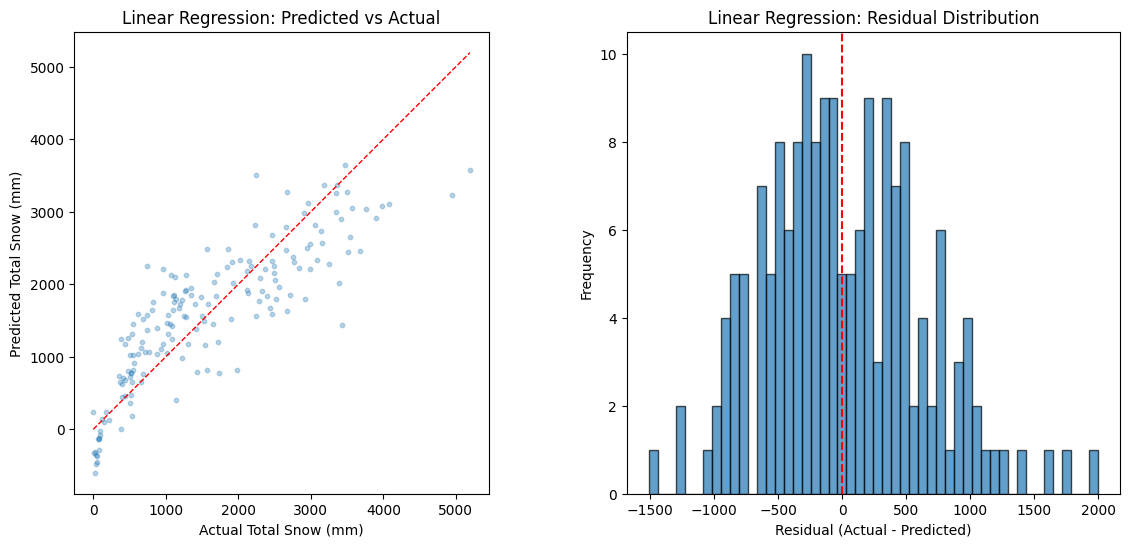


Best model: Linear Regression
Mean residual: 7.58
Std residual: 610.61


In [ ]:
# best model based on test RMSE
best_model_name = results_df.index[0]
best_preds = predictions[best_model_name]

fig, axes = plt.subplots(1, 2, figsize = (14, 6))

# scatterplot predicted vs actual
ax = axes[0]
ax.scatter(y_test, best_preds, alpha = 0.3, s = 10)
max_val = max(y_test.max(), best_preds.max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth = 1)
ax.set_xlabel('Actual Total Snow (mm)')
ax.set_ylabel('Predicted Total Snow (mm)')
ax.set_title(f'{best_model_name}: Predicted vs Actual')
ax.set_aspect('equal')

# residual distribution histogram
ax = axes[1]
residuals = y_test - best_preds
ax.hist(residuals, bins = 50, edgecolor = 'black', alpha = 0.7)
ax.axvline(0, color = 'r', linestyle = '--')
ax.set_xlabel('Residual (Actual - Predicted)')
ax.set_ylabel('Frequency')
ax.set_title(f'{best_model_name}: Residual Distribution')
plt.show()

print(f"\nBest model: {best_model_name}")
print(f"Mean residual: {residuals.mean():.2f}")
print(f"Std residual: {residuals.std():.2f}")

# Trend Analysis

Regional Snowfall Trend Analysis
Region 0 – Southern VT:
OLS slope: -82.3 mm/year  (p=0.0162)
R^2: 0.348
Kendall tau: -0.550  (p=0.0024)
Significant at alpha=0.05? YES

Region 1 – Central VT:
OLS slope: -0.1 mm/year  (p=0.9979)
R^2: 0.000
Kendall tau: -0.100  (p=0.6259)
Significant at alpha=0.05? no

Region 2 – Northern VT:
OLS slope: -32.3 mm/year  (p=0.2053)
R^2: 0.105
Kendall tau: -0.206  (p=0.2706)
Significant at alpha=0.05? no

Region 3 – NEK / Border:
OLS slope: -52.8 mm/year  (p=0.0569)
R^2: 0.208
Kendall tau: -0.333  (p=0.0574)
Significant at alpha=0.05? no



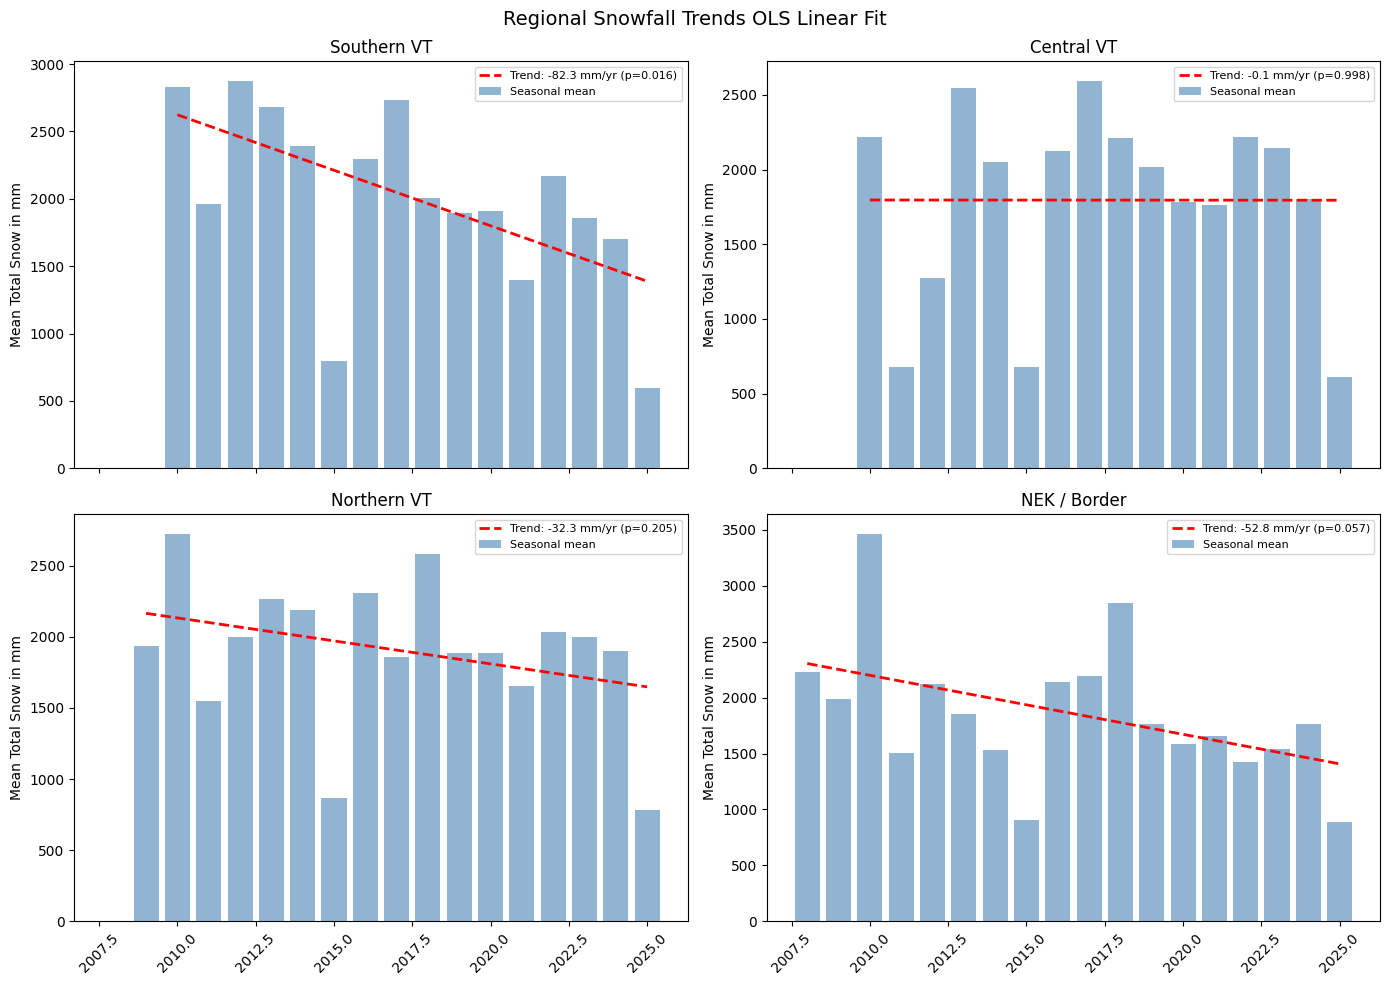

In [ ]:
# Per region Snowfall Trends
# OLS linear trend slope in mm/year with p value
# Mann Kendall trend test

# Regional seasonal averages
regional_stats = seasonal_stats.groupby(['region', 'county_region_name', 'winter_year']).agg(
    mean_total_snow = ('total_snow', 'mean'),
    mean_snow_days = ('snow_days', 'mean'),
    mean_snow_season_days = ('snow_season_days', 'mean'),
    mean_snow_prcp_ratio = ('snow_prcp_ratio', 'mean'),
    n_stations = ('STATION', 'nunique'),
).reset_index()

print("Regional Snowfall Trend Analysis")

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
axes = axes.flatten()

for idx, (region_id, region_name) in enumerate(sorted(COUNTY_REGION_NAMES.items())):
    subset = regional_stats[regional_stats['region'] == region_id].copy()
    subset = subset.sort_values('winter_year')

    if len(subset) < 5:
        print(f"  Region {region_id} ({region_name}): too few data points for trend\n")
        continue

    x = subset['winter_year'].values.astype(float)
    y = subset['mean_total_snow'].values

    # OLS linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    # Mann Kendall
    try:
        mk_result = stats.kendalltau(x, y)
        mk_tau = mk_result.statistic
        mk_p = mk_result.pvalue
    except Exception:
        mk_tau, mk_p = float('nan'), float('nan')

    print(f"Region {region_id} – {region_name}:")
    print(f"OLS slope: {slope:.1f} mm/year  (p={p_value:.4f})")
    print(f"R^2: {r_value**2:.3f}")
    print(f"Kendall tau: {mk_tau:.3f}  (p={mk_p:.4f})")
    sig = "YES" if p_value < 0.05 else "no"
    print(f"Significant at alpha=0.05? {sig}\n")

    # Plot
    ax = axes[idx]
    ax.bar(subset['winter_year'], y,
           alpha = 0.6, color = 'steelblue', label = 'Seasonal mean')
    ax.plot(x, intercept + slope * x, 'r--', linewidth=2,
            label=f'Trend: {slope:+.1f} mm/yr (p={p_value:.3f})')
    ax.set_title(f'{region_name}', fontsize=12)
    ax.set_ylabel('Mean Total Snow in mm')
    ax.legend(fontsize = 8)
    ax.tick_params(axis = 'x', rotation = 45)

plt.suptitle('Regional Snowfall Trends OLS Linear Fit', fontsize=14)
plt.tight_layout()
plt.show()

# Future Forecasting/predictions

Regional Snowfall Forecasts Next 5 Seasons
 region  forecast_year  mean_predicted_snow  std_predicted_snow  n_stations
      0           2026           676.297803          289.555446          14
      0           2027           644.778338          190.265649          14
      0           2028           719.088221          246.734895          14
      0           2029           734.907932          257.166798          14
      0           2030           735.590832          258.132939          14
      1           2025          1074.087656                 NaN           1
      1           2026           698.986242          197.197529          10
      1           2027           727.188992          152.404151          10
      1           2028           756.032166          165.591401          10
      1           2029           769.646376          177.089924          10
      1           2030           751.103611          173.136733           9
      2           2025           398.536001  

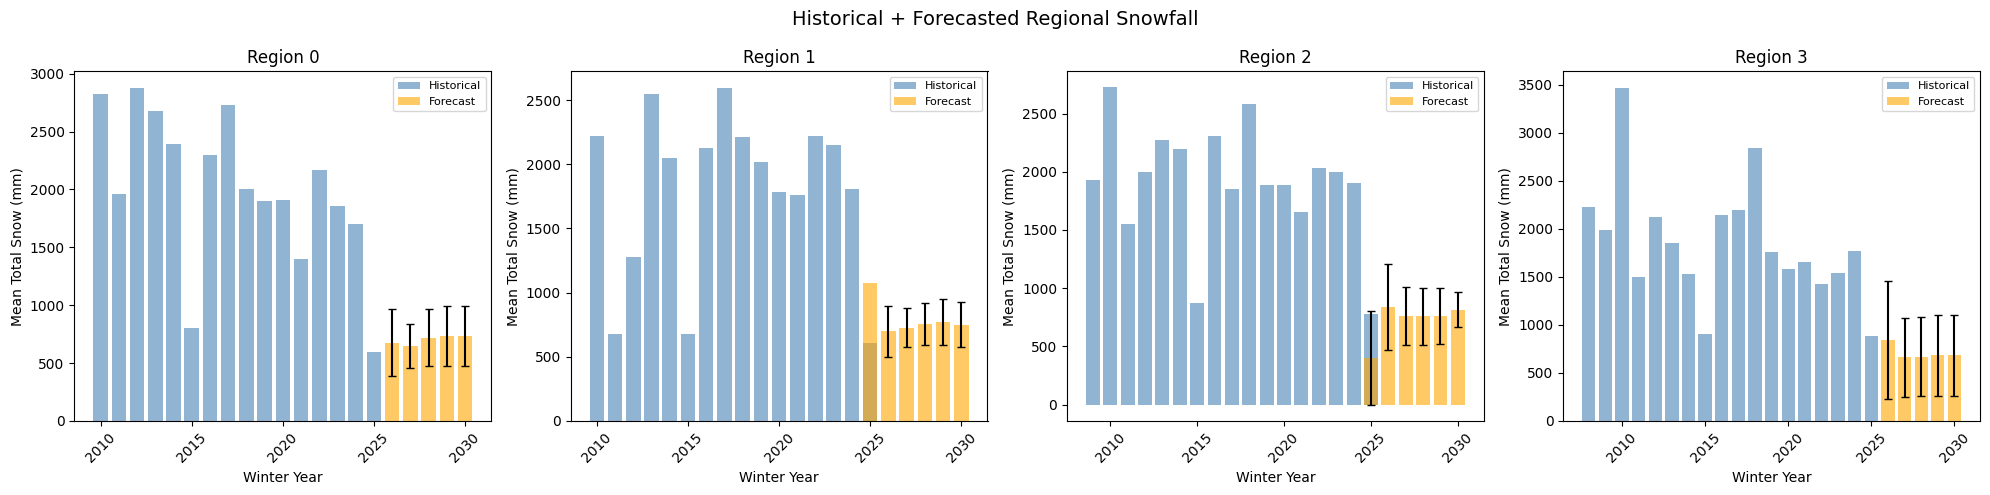

In [ ]:
# Compute regional historical stats for plotting
regional_stats = seasonal_stats.groupby(['region', 'winter_year']).agg(
    total_snow=('total_snow', 'mean'),
    total_prcp=('total_prcp', 'mean'),
    snow_days=('snow_days', 'mean'),
    n_stations=('STATION', 'nunique'),
).reset_index()

# Next 5 seasons
# For forecasting we retrain the best tree based model on all datadwasdasdwasdwasd
# Project forward by incrementing year_numeric and using last known lags
best_model_for_forecast = RandomForestRegressor(
    n_estimators = 200, max_depth = 15, min_samples_leaf = 5,
    random_state = 42, n_jobs = -1
)
best_model_for_forecast.fit(
    ml_ready[FEATURE_COLS].values,
    ml_ready[TARGET_COL].values
)

# Get last known data per station for bootstrapping forecasts
last_known = ml_ready.sort_values('winter_year').groupby('STATION').last().reset_index()

forecast_years = 5
all_forecasts = []

# Each year updates lags from previous prediction
current_state = last_known.copy()

for yr_offset in range(1, forecast_years + 1):
    forecast_rows = current_state.copy()
    forecast_rows['winter_year'] = last_known['winter_year'] + yr_offset
    forecast_rows['year_numeric'] = last_known['year_numeric'] + yr_offset

    X_forecast = forecast_rows[FEATURE_COLS].values
    predicted = best_model_for_forecast.predict(X_forecast)
    forecast_rows['predicted_snow'] = predicted
    forecast_rows['forecast_year'] = forecast_rows['winter_year']

    all_forecasts.append(forecast_rows[['STATION', 'NAME', 'region',
                                         'forecast_year', 'predicted_snow',
                                         'latitude', 'longitude', 'elevation']])

    # Shift lags for next iteration: lag1 <- predicted, lag2 <- old lag1, lag3 <- old lag2
    current_state['snow_lag3'] = current_state['snow_lag2']
    current_state['snow_lag2'] = current_state['snow_lag1']
    current_state['snow_lag1'] = predicted

    current_state['prcp_lag3'] = current_state['prcp_lag2']
    current_state['prcp_lag2'] = current_state['prcp_lag1']
    # prcp lags keep last known ratios as approximation

    current_state['snow_days_lag3'] = current_state['snow_days_lag2']
    current_state['snow_days_lag2'] = current_state['snow_days_lag1']

    current_state['ratio_lag3'] = current_state['ratio_lag2']
    current_state['ratio_lag2'] = current_state['ratio_lag1']

    # Update rolling averages
    # snow_roll3: mean of last 3 snow values (use lags)
    current_state['snow_roll3'] = (
        current_state['snow_lag1'] + current_state['snow_lag2'] + current_state['snow_lag3']
    ) / 3.0
    current_state['snow_roll5'] = current_state['snow_roll3']  # approximation

forecasts_df = pd.concat(all_forecasts, ignore_index=True)

# Regional forecast summary
regional_forecast = forecasts_df.groupby(['region', 'forecast_year']).agg(
    mean_predicted_snow=('predicted_snow', 'mean'),
    std_predicted_snow=('predicted_snow', 'std'),
    n_stations=('STATION', 'nunique'),
).reset_index()

print("Regional Snowfall Forecasts Next 5 Seasons")
print(regional_forecast.to_string(index=False))

# Plot forecasts with historical data
n_regions = len(COUNTY_REGION_NAMES)
fig, axes = plt.subplots(1, n_regions, figsize = (5 * n_regions, 5), squeeze = False)
for i, region in enumerate(sorted(regional_stats['region'].unique())):
    ax = axes[0, i]

    # Historical data
    hist = regional_stats[regional_stats['region'] == region]
    ax.bar(hist['winter_year'], hist['total_snow'],
           alpha=0.6, label='Historical', color='steelblue')

    # Forecast
    fcast = regional_forecast[regional_forecast['region'] == region]
    ax.bar(fcast['forecast_year'], fcast['mean_predicted_snow'],
           alpha=0.6, label='Forecast', color='orange')
    ax.errorbar(fcast['forecast_year'], fcast['mean_predicted_snow'],
                yerr=fcast['std_predicted_snow'], fmt='none', color='black', capsize=3)

    ax.set_title(f'Region {region}')
    ax.set_xlabel('Winter Year')
    ax.set_ylabel('Mean Total Snow (mm)')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Historical + Forecasted Regional Snowfall', fontsize=14)
plt.tight_layout()
plt.show()